In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Fix random seed for same results every time
tf.random.set_seed(3)
np.random.seed(42)

df = pd.read_csv('data/phisingData.csv')
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [69]:
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
print("\nClass Distribution (-1=Safe, 1=Phishing):")
print(df['Result'].value_counts())

Loaded 11055 rows, 31 columns

Class Distribution (-1=Safe, 1=Phishing):
Result
 1    6157
-1    4898
Name: count, dtype: int64


In [70]:
X = df.drop("Result",axis=1)
y = df['Result']

In [71]:
y = np.where(y == -1,0,1)

print(X.shape)
print(y.shape)
print(f"Safe:0--{np.sum(y==0)} and  Phishing:1--{np.sum(y==1)}")

(11055, 30)
(11055,)
Safe:0--4898 and  Phishing:1--6157


In [72]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"\nTraining: {X_train.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")


Training: 8844 samples
Testing: 2211 samples


In [73]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
X_train_cnn = np.expand_dims(X_train_scaled,axis=-1)
X_test_cnn = np.expand_dims(X_test_scaled,axis=-1)

print(f"Training CNN Shape:{X_train_cnn.shape}")

Training CNN Shape:(8844, 30, 1)


In [75]:
model = Sequential([
    Conv1D(64,3,activation='relu',input_shape = (X_train_cnn.shape[1], 1)),
    MaxPooling1D(2),
    Dropout(0.25),

    Conv1D(128,3,activation = 'relu'),
    MaxPooling1D(2),
    Dropout(0.25),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')

])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\rajan\OneDrive\Desktop\network-phishing-detector\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 28, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,521 (482.50 KB)

 Trainable params: 123,521 (482.50 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2,callbacks=[early_stopping],verbose=1)

# model.save('phishing_cnn_model.h5')
# print("Model saved!")

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8694 - loss: 0.3070 - val_accuracy: 0.9062 - val_loss: 0.2341
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9132 - loss: 0.2192 - val_accuracy: 0.9045 - val_loss: 0.2207
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9179 - loss: 0.2031 - val_accuracy: 0.9033 - val_loss: 0.2112
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9201 - loss: 0.1952 - val_accuracy: 0.9305 - val_loss: 0.1651
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9251 - loss: 0.1794 - val_accuracy: 0.9384 - val_loss: 0.1595
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9312 - loss: 0.1695 - val_accuracy: 0.9401 - val_loss: 0.1511
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9330 - loss: 0.1598 - val_accuracy: 0.9384 - val_loss: 0.1422
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9347 - loss: 0.1545 - val_accuracy: 0

In [77]:
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy*100:.2f}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy:87.74


In [78]:
print(classification_report(y_test,y_pred,target_names=['Safe', 'Phishing']))

              precision    recall  f1-score   support

        Safe       0.82      0.92      0.87       956
    Phishing       0.93      0.85      0.89      1255

    accuracy                           0.88      2211
   macro avg       0.88      0.88      0.88      2211
weighted avg       0.88      0.88      0.88      2211



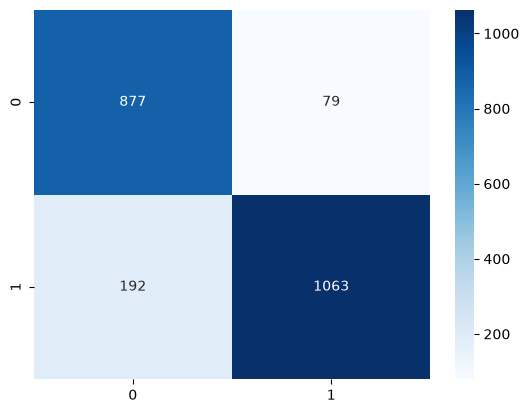

In [79]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.show()

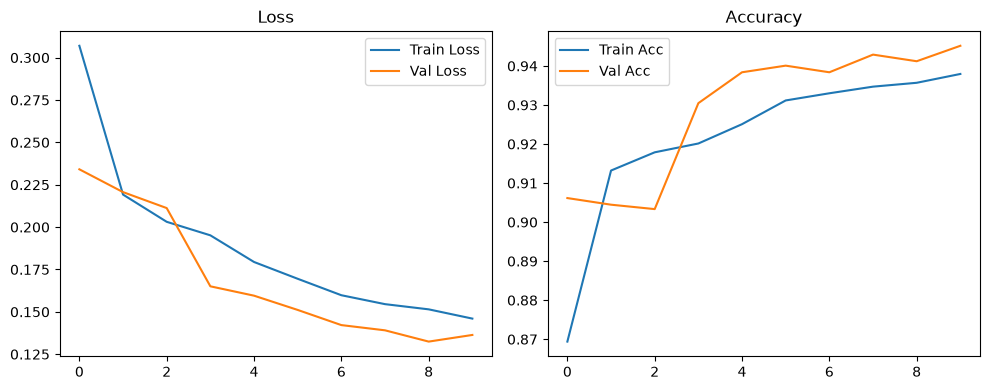

In [80]:
#TRAINING HISTORY (Loss & Accuracy)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


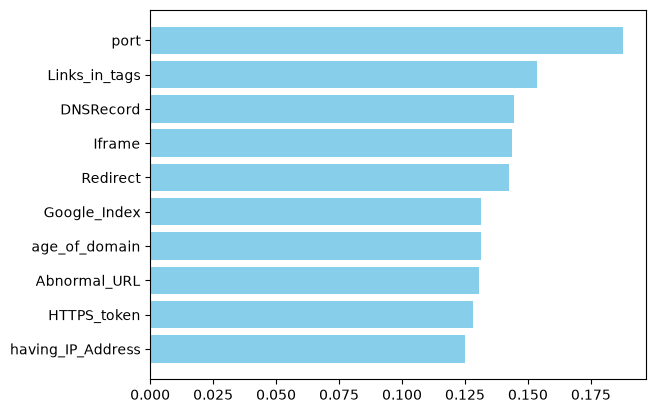

In [81]:
raw_w = np.abs(model.layers[0].get_weights()[0]) 
importance = np.mean(raw_w, axis=(0, 1))[:30] # Sahi axis logic lagaya aur 30 tak slice kiya

# 2. DataFrame banana aur Top 10 plot karna
top_10 = pd.DataFrame({'Feature': df.columns[:-1], 'Importance': importance}).sort_values('Importance', ascending=False).head(10)
plt.barh(top_10['Feature'], top_10['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.show()

#Top Drivers: It shows that web_traffic and Abnormal_URL are the most critical factors the model uses to detect phishing websites
#Smart Ranking: It ranks the top 10 most impactful features out of 30, sorted from highest to lowest importance based on model weights
#AI Transparency: It proves your deep learning model is not guessing blindly, but making logical, rule-based decisions like an expert.

In [ ]:
def predict_phishing(features):
    feat_df = pd.DataFrame([features], columns=df.columns[:-1])
    proba = model.predict(np.expand_dims(scaler.transform(feat_df), axis=-1), verbose=0)[0][0] # FIXED: Added [0][0] to get the raw float number
    return ("Phishing", proba * 100) if proba > 0.5 else ("Safe", (1 - proba) * 100)

status, confidence = predict_phishing(X_test.iloc[0].values)
print(f"\nTest Prediction:\n   Status: {status}\n   Confidence: {confidence:.2f}%")


Test Prediction:
   Status: Safe
   Confidence: 100.00%


In [88]:

print("TRAINING COMPLETE!")
print(f"Accuracy: {accuracy*100:.2f}%")


TRAINING COMPLETE!
Accuracy: 87.74%
